In [1]:
# Robust loader handling both old "batch" and "flattened" merged formats

import glob
import pickle
import pandas as pd

files = sorted(glob.glob("data_batches/merged_*.pkl") + glob.glob("data_batches/batch_*.pkl"))

rows = []
for fp in files:
    with open(fp, "rb") as f:
        data = pickle.load(f)
    
    # Data may be:
    # 1) A dict with "params" (N×7 array) and "results" (list of dicts)
    # 2) A list whose elements are either:
    #    a) batch-dicts with "params"/"results" (old-merged)
    #    b) single-point dicts with "params" (length-7 array) and "result"/"results" (dict)
    
    # Helper to flatten a batch-dict
    def flatten_batch(batch):
        ps = batch["params"]
        rs = batch["results"]
        for p, r in zip(ps, rs):
            yield p, r
    
    # Helper to flatten a single-point dict
    def flatten_point(entry):
        p = entry["params"]
        # entry may use "result" or "results"
        r = entry.get("result", entry.get("results"))
        if isinstance(r, list):  # sometimes "results" is a list of 1 dict
            r = r[0]
        yield p, r
    
    # Now dispatch
    if isinstance(data, dict) and "params" in data and "results" in data:
        # Single batch file
        for p, r in flatten_batch(data):
            row = {
                "m_A":      p[0],
                "m_phi":    p[1],
                "sin_ba":   p[2],
                "tan_beta": p[3],
                "lambda_6": p[4],
                "lambda_7": p[5],
                "m12_2":    p[6],
                **r
            }
            rows.append(row)
    
    elif isinstance(data, list):
        # Merged file: list of entries
        for entry in data:
            if isinstance(entry, dict):
                if "params" in entry and "results" in entry:
                    # This entry is a full batch
                    for p, r in flatten_batch(entry):
                        row = {
                            "m_A":      p[0],
                            "m_phi":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                elif "params" in entry:
                    # Single-point entry
                    for p, r in flatten_point(entry):
                        row = {
                            "m_A":      p[0],
                            "m_phi":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                else:
                    raise ValueError(f"Unexpected dict keys in entry from {fp}: {entry.keys()}")
            else:
                raise ValueError(f"Unexpected entry type in merged list from {fp}: {type(entry)}")
    else:
        raise ValueError(f"Unknown data structure in file {fp}: {type(data)}")

# 3) Build DataFrame and save to Parquet (or fallback to CSV)
df = pd.DataFrame(rows)

try:
    df.to_parquet("data_train/dataset_full.parquet", index=False)
    print(f"Saved merged dataset with {len(df)} rows to dataset_full.parquet")
except Exception as e:
    print("Failed to write Parquet:", e)
    df.to_csv("data_train/dataset_full.csv", index=False)
    print("Saved merged dataset to dataset_full.csv")


Saved merged dataset with 324000 rows to dataset_full.parquet


In [2]:
df.dropna(inplace=True)

In [3]:
df.columns

Index(['m_A', 'm_phi', 'sin_ba', 'tan_beta', 'lambda_6', 'lambda_7', 'm12_2',
       'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'w_h2_bb',
       'w_h2_tautau', 'w_h2_uu', 'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga',
       'w_h2_Zga', 'w_h2_gg', 'w_h2_hh', 'w_total_h2', 'w_total_top',
       'branching_ratio_h2_gaga', 'lambda1', 'lambda2', 'lambda3', 'lambda4',
       'lambda5', 'lambda6', 'lambda7'],
      dtype='object')

# Training

In [4]:
print(
    sum(df["positivity_ok"]),
    sum(df["perturbativity_ok"]),
    sum(df["unitarity_ok"]) )

238203 145833 151295


Class counts:
positivity_ok        238203
perturbativity_ok    145833
unitarity_ok         151295
dtype: int64

=== Descriptive stats for positivity_ok == 1 ===
                            count          mean           std           min  \
m_A                      238203.0  1.793635e+02  5.311761e+01  1.250000e+02   
m_phi                    238203.0  3.000000e+02  2.354268e-02  2.999000e+02   
sin_ba                   238203.0  1.000000e+00  0.000000e+00  1.000000e+00   
tan_beta                 238203.0  1.000000e+04  0.000000e+00  1.000000e+04   
lambda_6                 238203.0  1.000000e-01  5.551127e-17  1.000000e-01   
lambda_7                 238203.0  0.000000e+00  0.000000e+00  0.000000e+00   
m12_2                    238203.0  3.335541e+00  2.239127e+00  6.299174e-01   
positivity_ok            238203.0  1.000000e+00  0.000000e+00  1.000000e+00   
unitarity_ok             238203.0  4.859049e-01  4.998023e-01  0.000000e+00   
perturbativity_ok        238203.0  4.744441e-01  

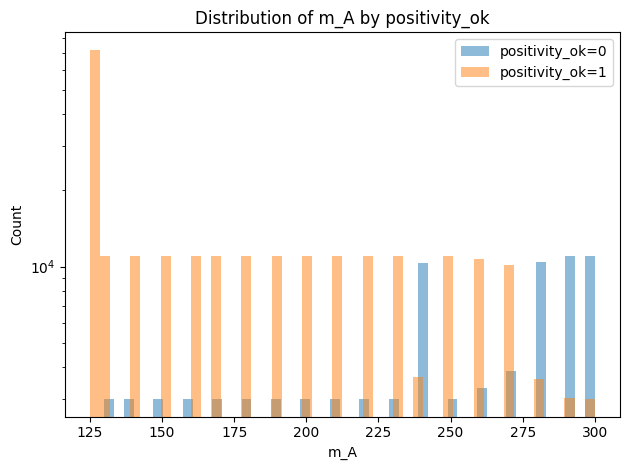

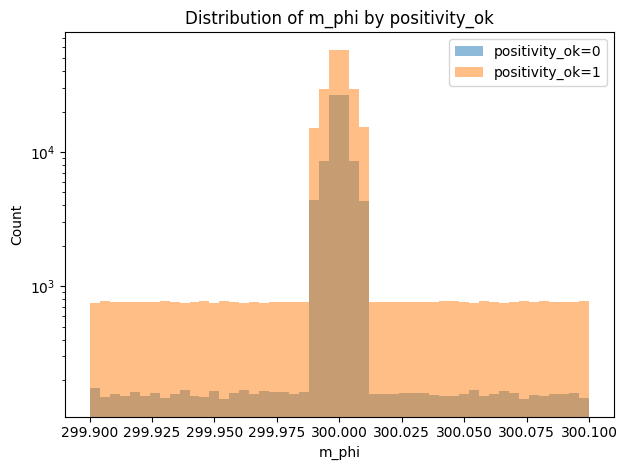

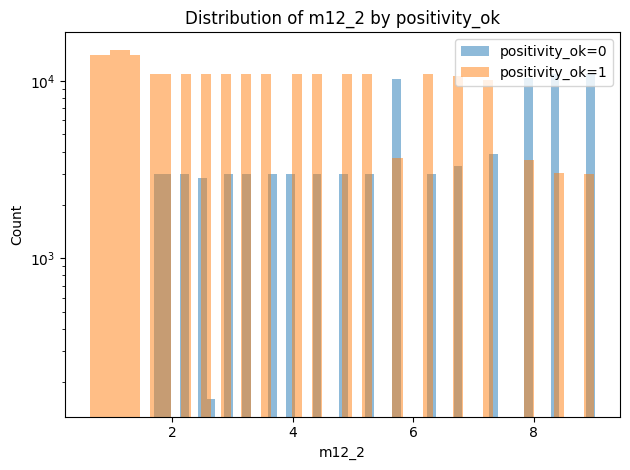

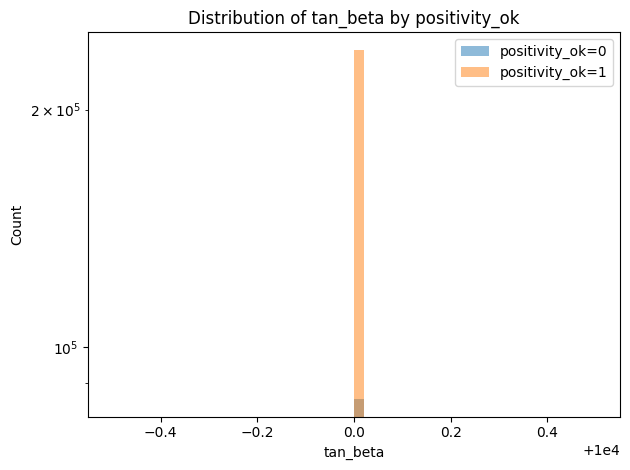

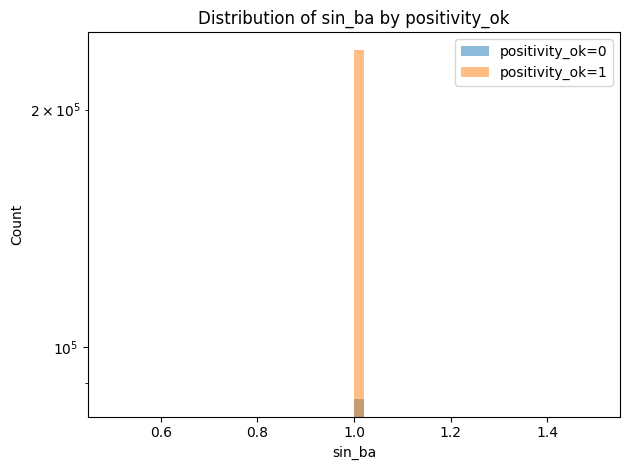

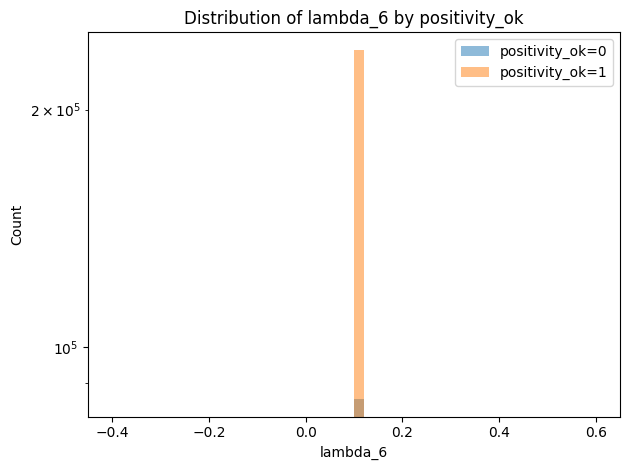

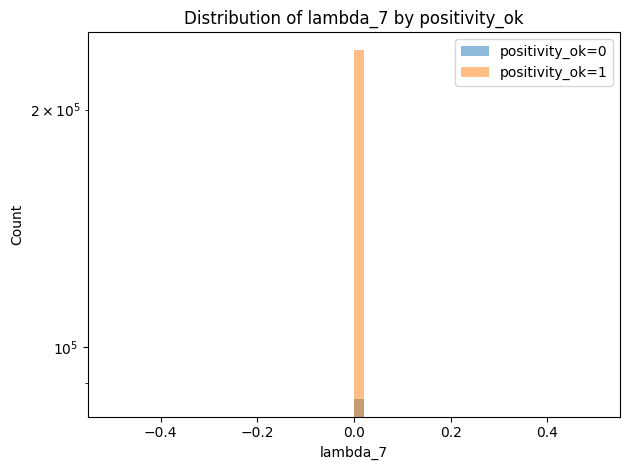

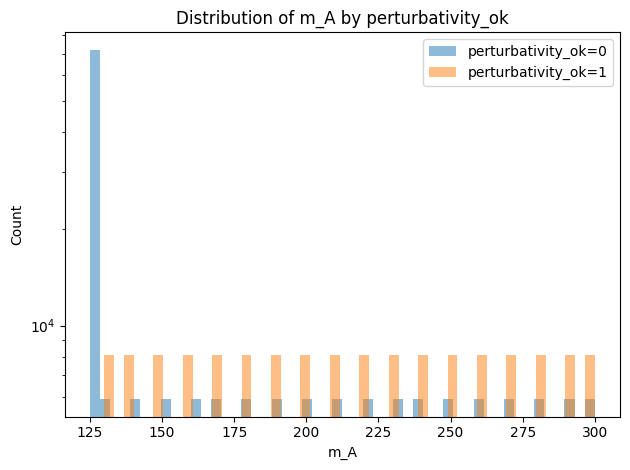

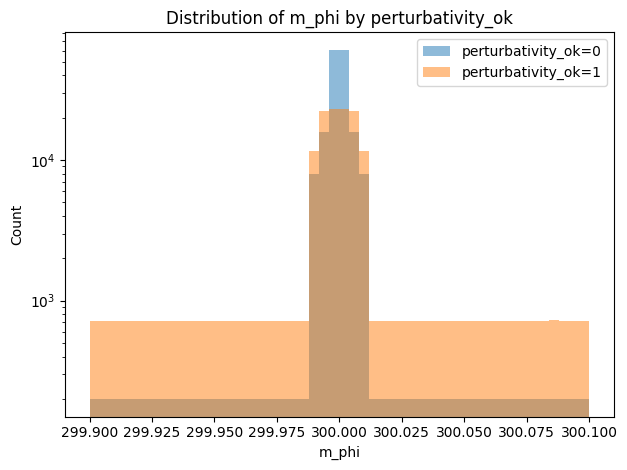

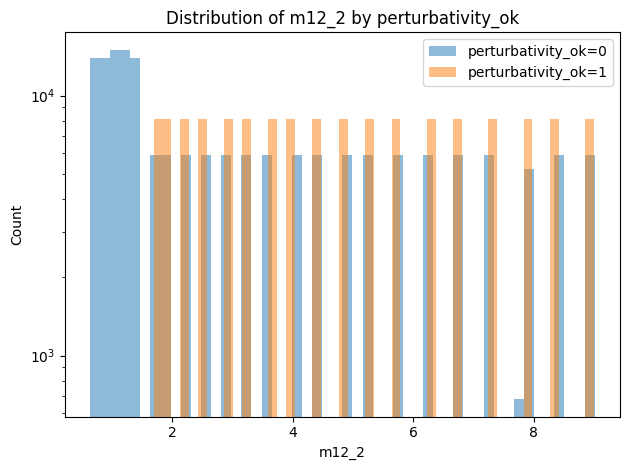

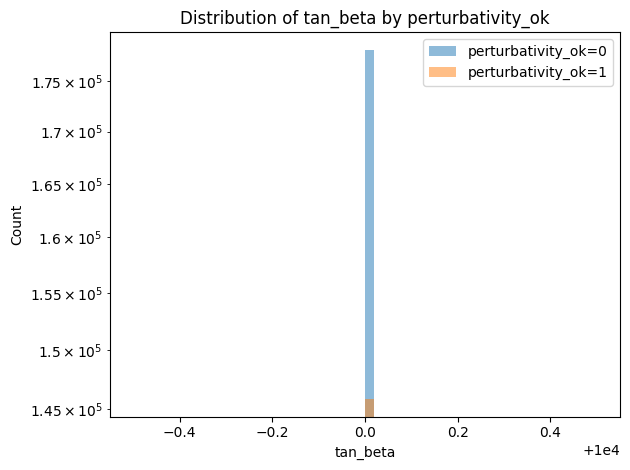

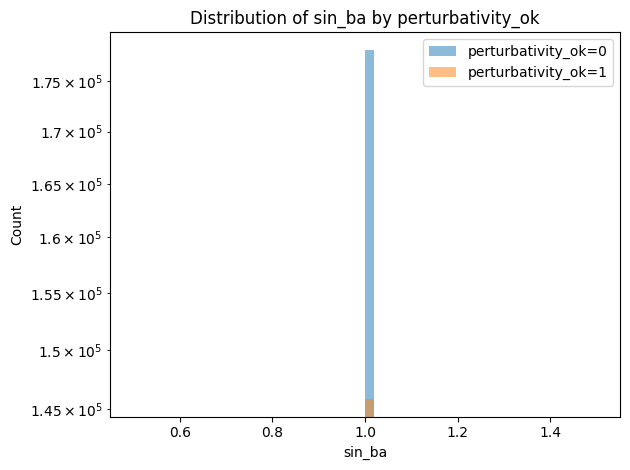

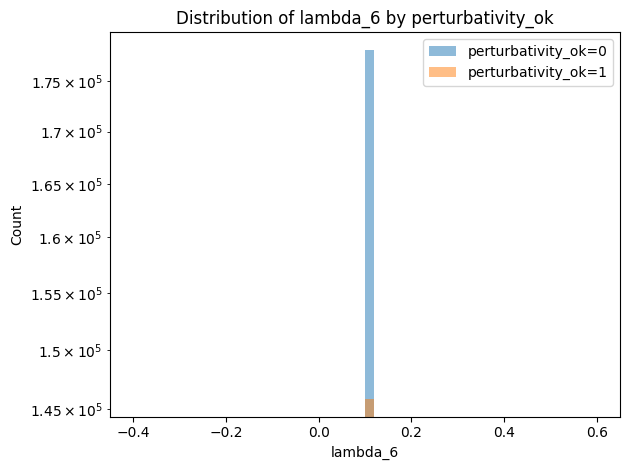

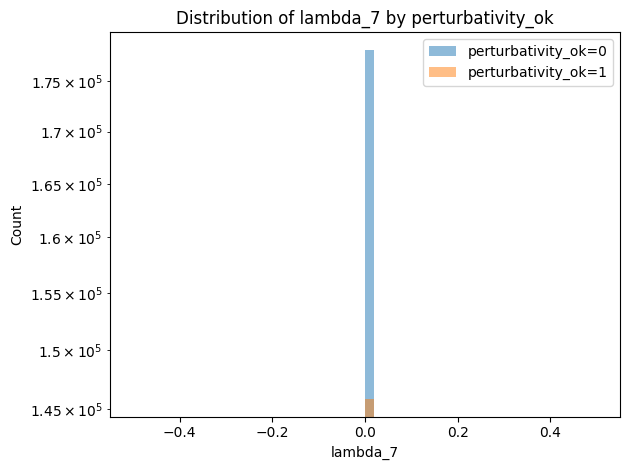

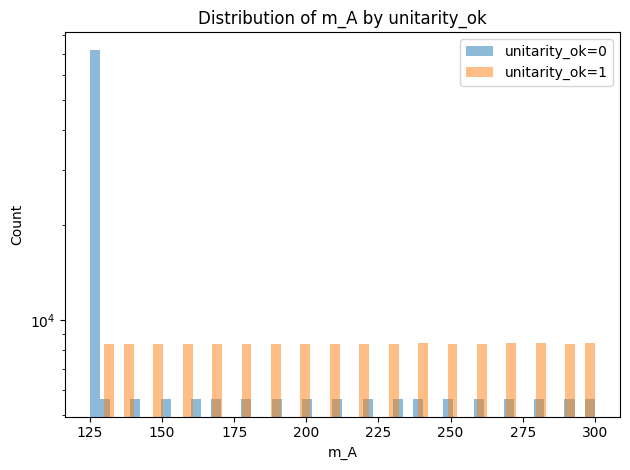

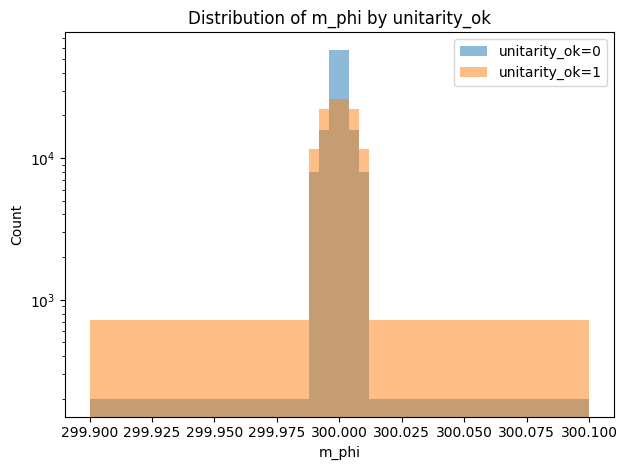

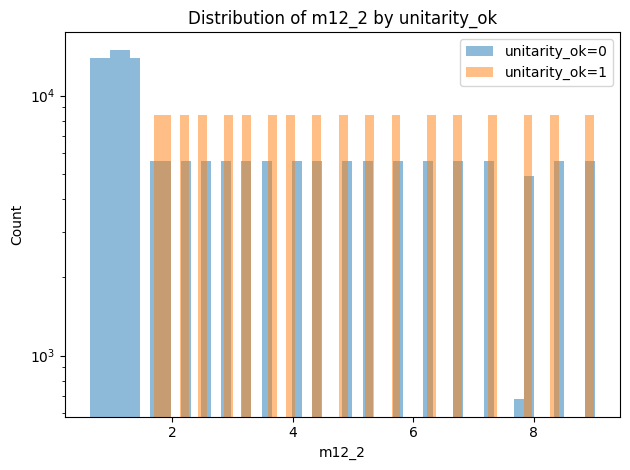

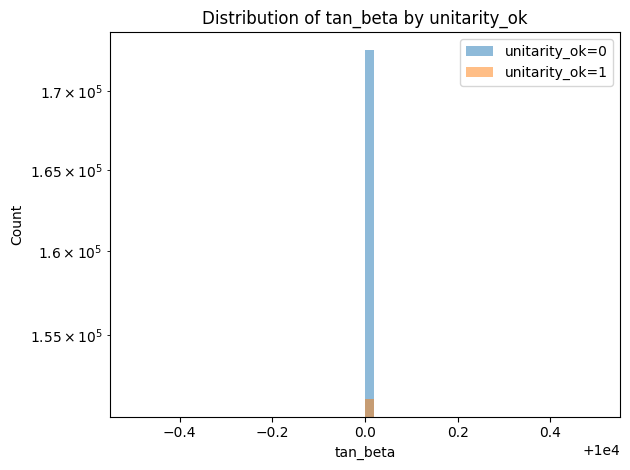

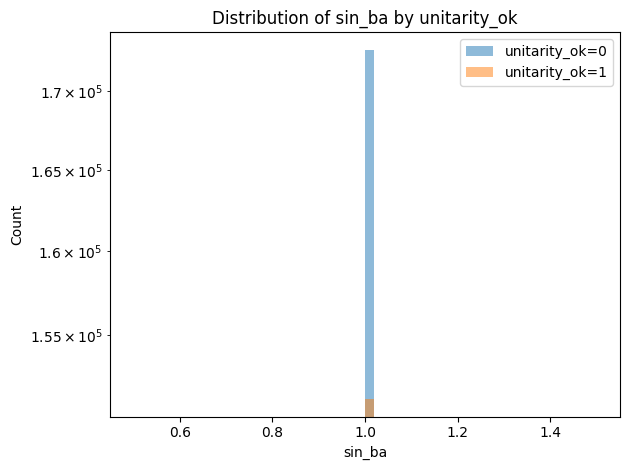

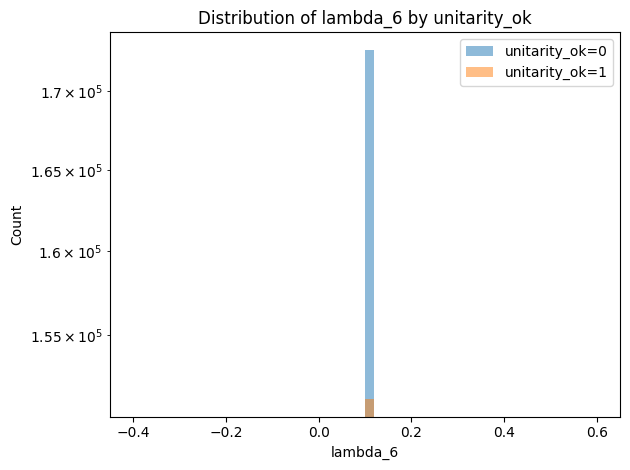

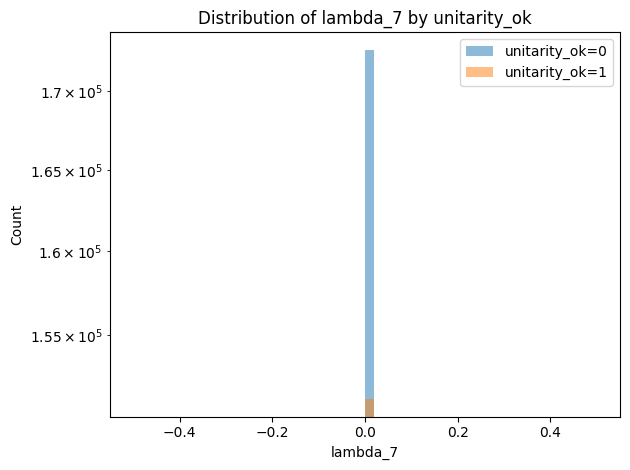

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# — assume df is already loaded —

# 1) Class counts
print("Class counts:")
print(df[["positivity_ok", "perturbativity_ok", "unitarity_ok"]].sum())
print()

# 2) Descriptive statistics for each “OK” class
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    print(f"=== Descriptive stats for {col} == 1 ===")
    print(df[df[col] == 1].describe().T)
    print()

# 3) Parameter ranges where each class==1
params = ["m_A","m_phi","m12_2","tan_beta","sin_ba","lambda_6","lambda_7"]
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    subset = df[df[col] == 1][params]
    mins = subset.min()
    maxs = subset.max()
    ranges = pd.concat([mins, maxs], axis=1)
    ranges.columns = ["min", "max"]
    print(f"=== Ranges for {col} == 1 ===")
    print(ranges)
    print()


# 6) Histograms by class for each parameter
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    for col in params:
        plt.figure()
        for cls_val in [0, 1]:
            subset = df[df[tipo] == cls_val]
            counts, bins, _ = plt.hist(subset[col], bins=50, alpha=0.5,
                    label=f"{tipo}={cls_val}")
            
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.yscale("log")
        plt.title(f"Distribution of {col} by {tipo}")
        plt.legend()
        plt.tight_layout()
        plt.show()




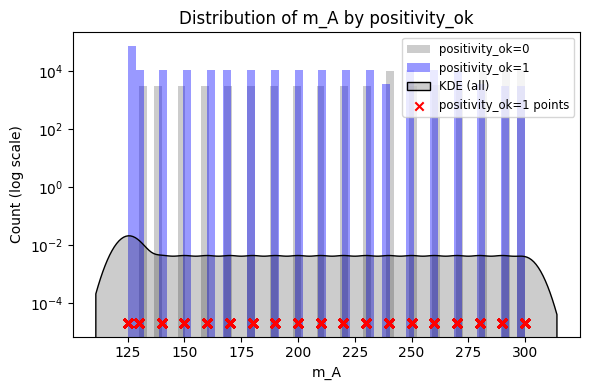

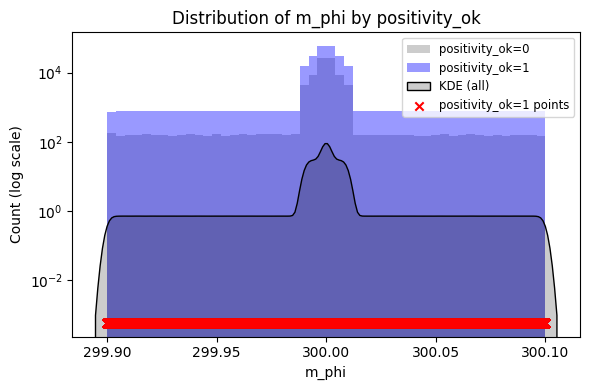

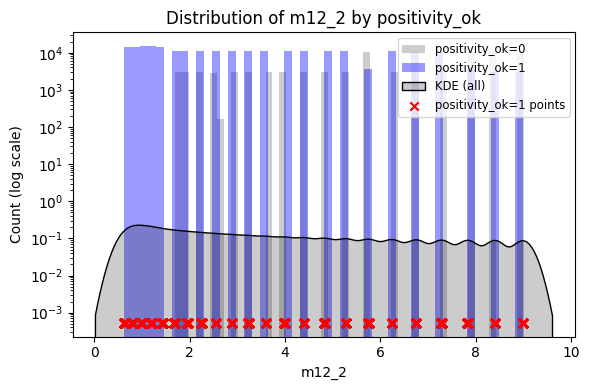

/tmp/ipykernel_386590/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


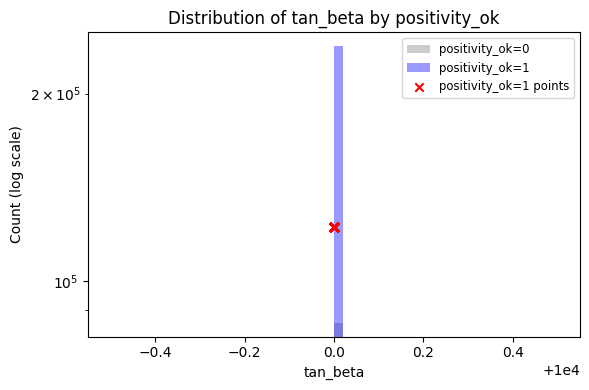

/tmp/ipykernel_386590/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


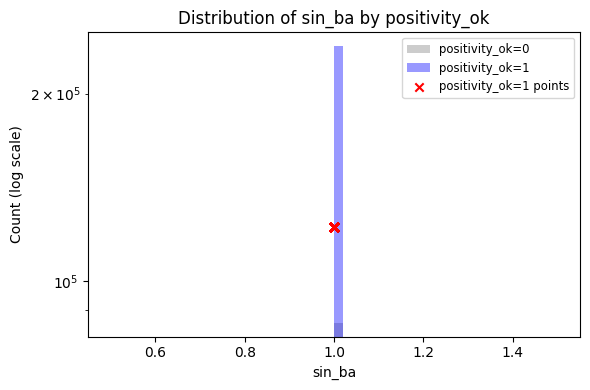

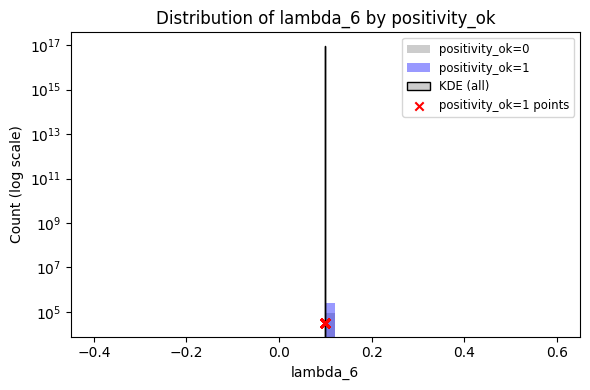

/tmp/ipykernel_386590/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


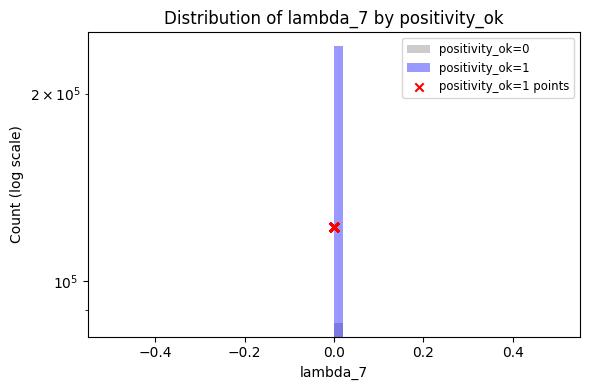

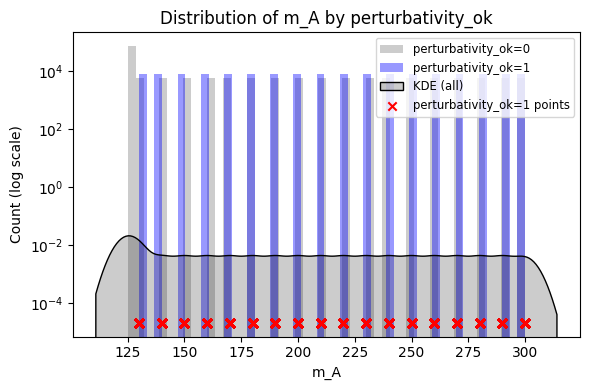

In [ ]:
import seaborn as sns

# 6) Histograms + KDE + rare-point markers by class for each parameter
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    for col in params:
        plt.figure(figsize=(6,4))
        
        # Plot histogram (log scale) for both classes
        for cls_val, color in zip([0,1], ["gray", "blue"]):
            subset = df[df[tipo] == cls_val]
            plt.hist(subset[col], bins=50, alpha=0.4, density=False, 
                     color=color, label=f"{tipo}={cls_val}")
        
        plt.yscale("log")
        plt.xlabel(col)
        plt.ylabel("Count (log scale)")
        
        # Overlay overall KDE
        sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")
        
        # Mark rare class points (cls_val=1) as red 'x' on x-axis
        xs = df[df[tipo] == 1][col].values
        # Place markers at a fraction of the y-axis bottom
        ymin, ymax = plt.ylim()
        y_annot = ymin * 1.5  # slightly above bottom
        plt.scatter(xs, np.full_like(xs, y_annot), marker="x", color="red", label=f"{tipo}=1 points")
        
        plt.title(f"Distribution of {col} by {tipo}")
        plt.legend(loc="upper right", fontsize="small")
        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 1) Load dataset
df = pd.read_parquet("data_train/dataset_full.parquet")

# 2) Derive perturbativity score
lambda_cols = ["lambda1", "lambda2", "lambda3", "lambda4", "lambda5", "lambda6", "lambda7"]
df["perturb_score"] = (df[lambda_cols]**2).sum(axis=1)

# 3) Descriptive statistics by class
desc_pos = df.groupby("perturbativity_ok")[lambda_cols + ["perturb_score"]].describe()
print("Descriptive statistics for perturbativity_ok:")
print(desc_pos)

# 4) Histograms of perturb_score by class
plt.figure()
for cls in [0, 1]:
    subset = df[df["perturbativity_ok"] == cls]
    plt.hist(subset["perturb_score"], bins=50, alpha=0.5, label=f"class {cls}")
plt.legend()
plt.xlabel("Perturbativity score")
plt.ylabel("Count")
plt.title("Distribution of perturbativity score by class")

# 5) Prepare features and labels
X = df[["m_A", "m_phi", "m_12", "tan_beta", "sin_ba", "lambda_6", "lambda_7", "perturb_score"]]
y = df["perturbativity_ok"]

# 6) Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 7) Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8) Model 1: Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Logistic Regression CV accuracy: {logreg_scores.mean():.3f}")

# 9) Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Random Forest CV accuracy: {rf_scores.mean():.3f}")

# 10) Hyperparameter tuning for RF
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best RF params:", grid.best_params_)
print(f"Tuned RF CV accuracy: {grid.best_score_:.3f}")


KeyError: "['lambda_1', 'lambda_2', 'lambda_3', 'lambda_4', 'lambda_5'] not in index"